<a href="https://colab.research.google.com/github/BWahot/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [ ]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columnss: {columns}")


Number of rows: 5268
Number of columnss: 13


In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
# Check for missing values across all columns
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a clean summary table
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage.round(2)
})

print("Missing values summary per column:")
print(missing_data_summary[missing_data_summary['Missing Values'] > 0])

# {
# Justification:
#   Leaving missing data untreated can break analytical functions, distort summary statistics, and cause visual plots to crash or misrepresent information. How we handle missing rows depends entirely on the data type (categorical text vs. numerical counts)

# Text Columns (Location, Operator, Route, Type, Summary):
#   Strategy: Imputation with a structural placeholder string such as "Unknown".
#   Reasoning: We cannot calculate a "mean" or "median" for words. Deleting the entire row would result in losing critical numerical data (like passenger counts) from other columns. Replacing them with a placeholder keeps the rows intact for analysis.
# Numerical Columns (Aboard, Fatalities, Ground):
#   Strategy:Imputation using the Median value of that specific column.
#   Reasoning: Airplane accidents vary drastically in size (some have 2 passengers, others have 300+). The mean (average) is easily skewed by extreme historical disasters. The median represents the true middle value and provides a realistic substitute without distorting overall statistical metrics.

# }


Missing values summary per column:
              Missing Values  Percentage (%)
Time                    2219           42.12
Location                  20            0.38
Operator                  18            0.34
Flight #                4199           79.71
Route                   1707           32.40
Type                      27            0.51
Registration             335            6.36
cn/In                   1228           23.31
Aboard                    22            0.42
Fatalities                12            0.23
Ground                    22            0.42
Summary                  390            7.40


In [ ]:
fatality_locations = df[['Date','Location','Aboard','Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
highest_fatality_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(f"Date of the highest fatalities: {highest_fatality_row['Date']}")
print(f"Number of fatalities: {highest_fatality_row['Fatalities']}")

Date of the highest fatalities: 03/27/1977
Number of fatalities: 583.0


In [ ]:
zero_fatalities_df = fatality_locations[fatality_locations['Fatalities'] == 0]
count_zero_fatalities = len(zero_fatalities_df)
print(f"Are there crashes with no fatalities? {'Yes' if count_zero_fatalities > 0 else 'No'}")
print(f"Number of crashes with zero fatalities: {count_zero_fatalities}")

Are there crashes with no fatalities? Yes
Number of crashes with zero fatalities: 58


In [ ]:
split_locations = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

fatality_locations['Region'] = split_locations[0].str.strip()
fatality_locations['State_Country'] = split_locations[1].str.strip()

fatality_locations[['Location', 'Region', 'State_Country']].head()

,Location,Region,State_Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada","Victoria, British Columbia",Canada
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany


In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


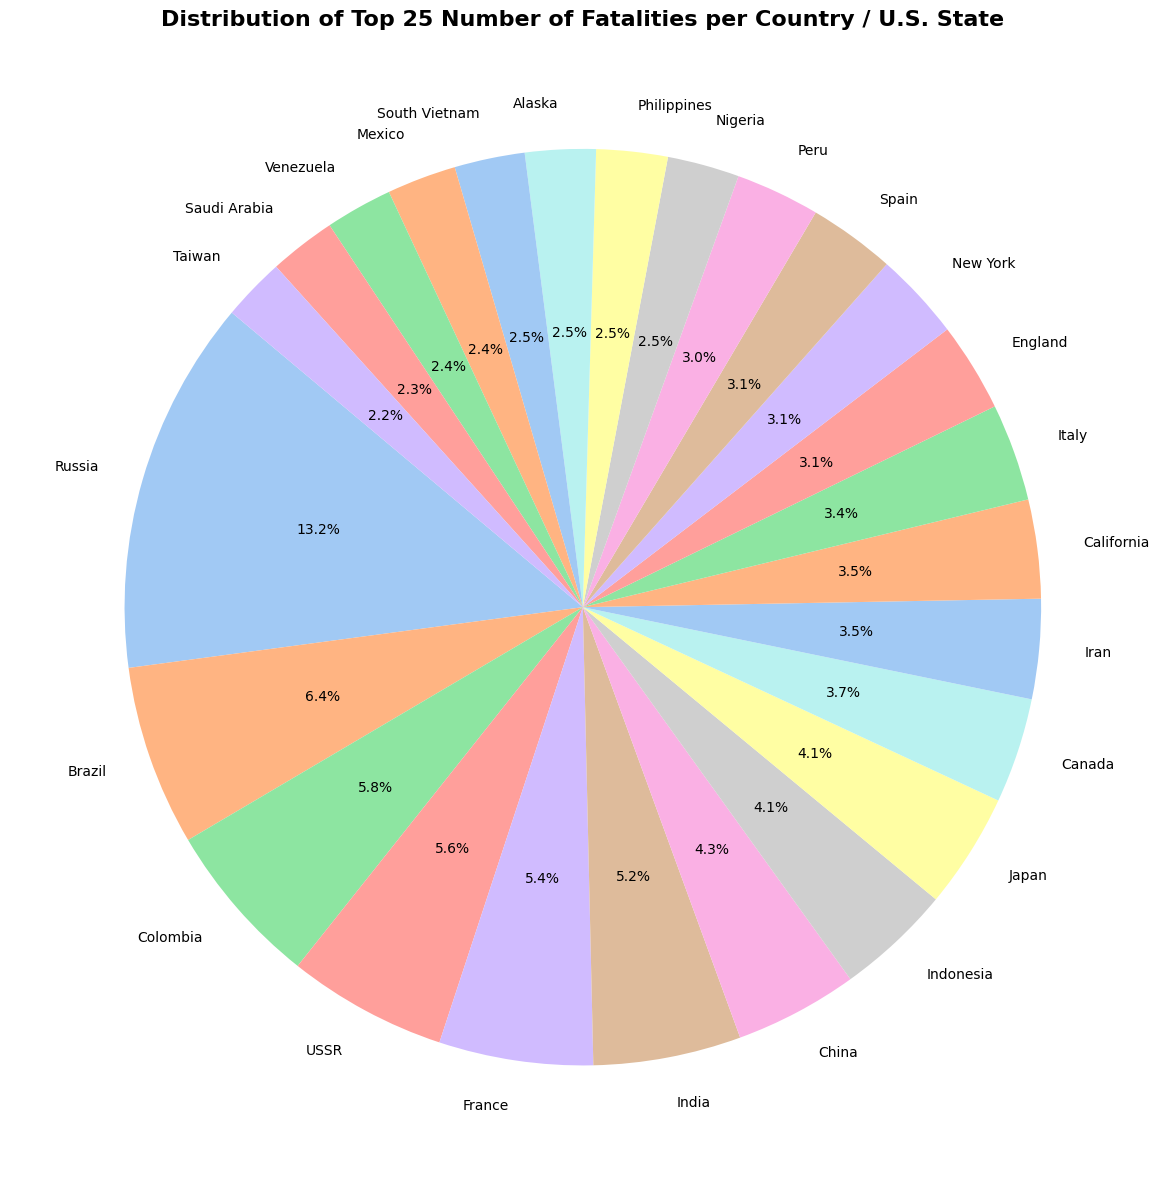

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by the state/country column, sum the fatalities, and get the top 25
top_25_countries = (
    fatality_locations.groupby('State_Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

# Set a Seaborn color palette for the chart
colors = sns.color_palette('pastel')[0:25]

# Generate the pie chart
plt.figure(figsize=(12, 12))
plt.pie(
    top_25_countries,
    labels=top_25_countries.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Distribution of Top 25 Number of Fatalities per Country / U.S. State', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

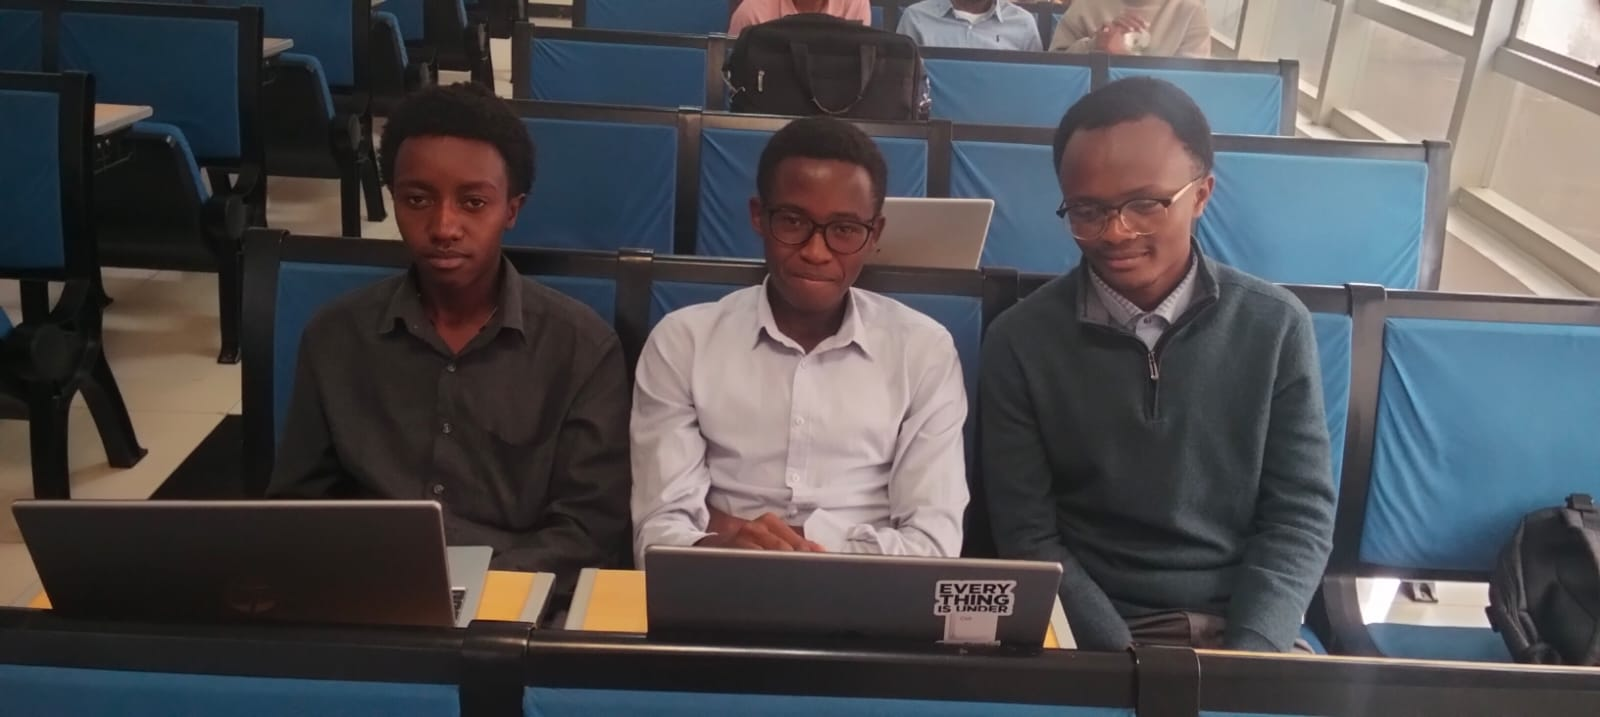